# Titanic Survival Prediction
Predict `Survived` using **Logistic Regression**, **SVM** and **XGBoost**, then compare them.


## 1. Import Libraries

In [41]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

In [3]:
print(path)

/Users/evakhromeeva/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1


In [4]:
df = pd.read_csv(os.path.join(path, "Titanic-Dataset.csv"))
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 3. Data Understanding

### 3.1 First Look

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### 3.2 Shape & Info

In [7]:
print('Shape:', df.shape)
df.info()

Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


### 3.3 Statistical Summary

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 3.4 Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

### 3.5 Missing Values

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 4. EDA

### 4.1 Target Distribution

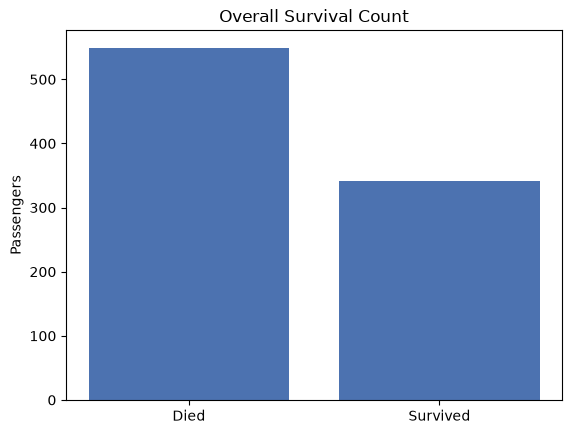

In [11]:
counts = df['Survived'].value_counts().sort_index()

plt.bar(['Died', 'Survived'], counts.values, color='#4c72b0')
plt.title('Overall Survival Count')
plt.ylabel('Passengers')
plt.show()

### 4.2 Survival by Sex

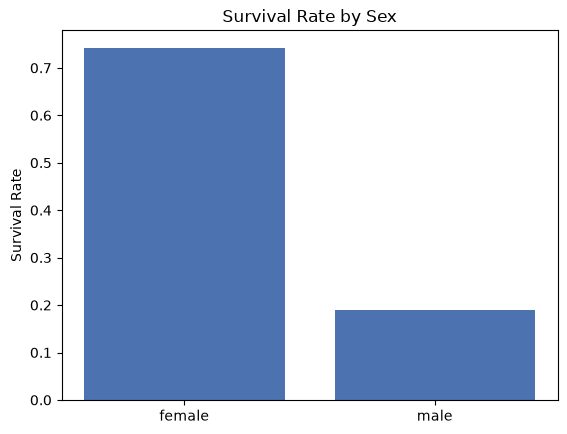

In [12]:
rate = df.groupby('Sex')['Survived'].mean()

plt.bar(rate.index, rate.values, color='#4c72b0')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

### 4.3 Survival by Passenger Class

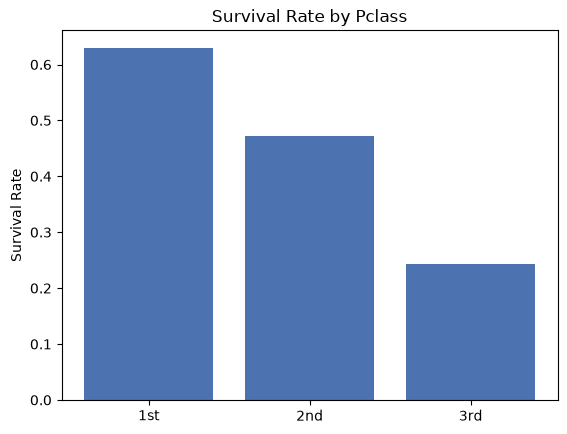

In [13]:
rate = df.groupby('Pclass')['Survived'].mean()

plt.bar(['1st', '2nd', '3rd'], rate.values, color='#4c72b0')
plt.title('Survival Rate by Pclass')
plt.ylabel('Survival Rate')
plt.show()

### 4.4 Survival by Class and Sex

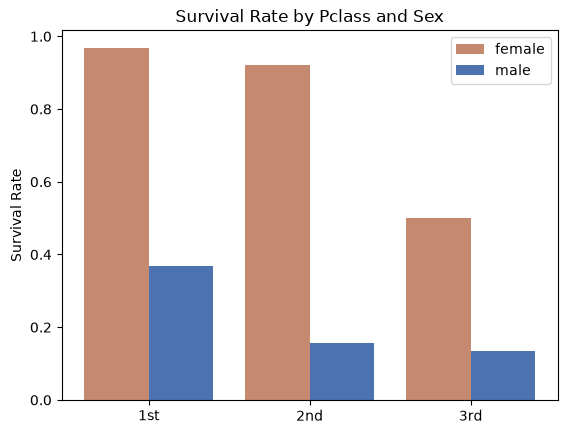

In [14]:
rate = df.pivot_table(values='Survived', index='Pclass', columns='Sex')
x = np.arange(3)

plt.bar(x - 0.2, rate['female'], width=0.4, label='female', color='#c4896e')
plt.bar(x + 0.2, rate['male'], width=0.4, label='male', color='#4c72b0')
plt.xticks(x, ['1st', '2nd', '3rd'])
plt.title('Survival Rate by Pclass and Sex')
plt.ylabel('Survival Rate')
plt.legend()
plt.show()

### 4.5 Age Distribution

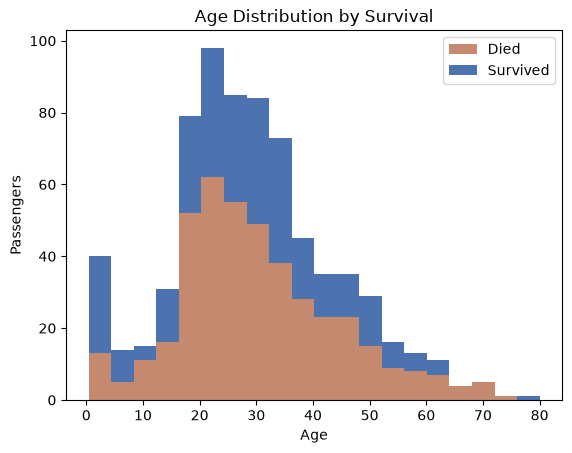

In [15]:
died = df[df['Survived'] == 0]['Age'].dropna()
survived = df[df['Survived'] == 1]['Age'].dropna()

plt.hist([died, survived], bins=20, stacked=True, color=["#c4896e", '#4c72b0'], label=['Died', 'Survived'])
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Passengers')
plt.legend()
plt.show()

### 4.6 Survival by Embarked

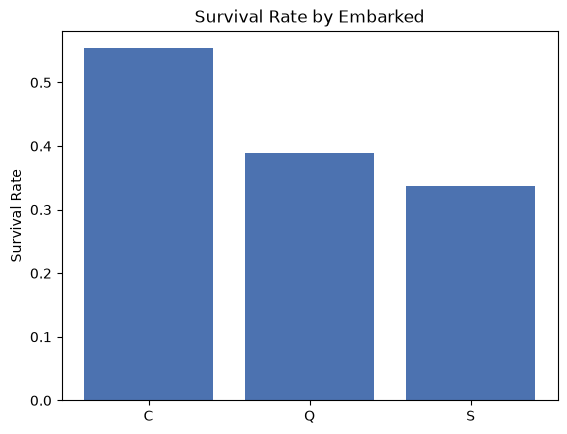

In [16]:
rate = df.groupby('Embarked')['Survived'].mean()

plt.bar(rate.index, rate.values, color='#4c72b0')
plt.title('Survival Rate by Embarked')
plt.ylabel('Survival Rate')
plt.show()

### 4.7 Correlation Heatmap

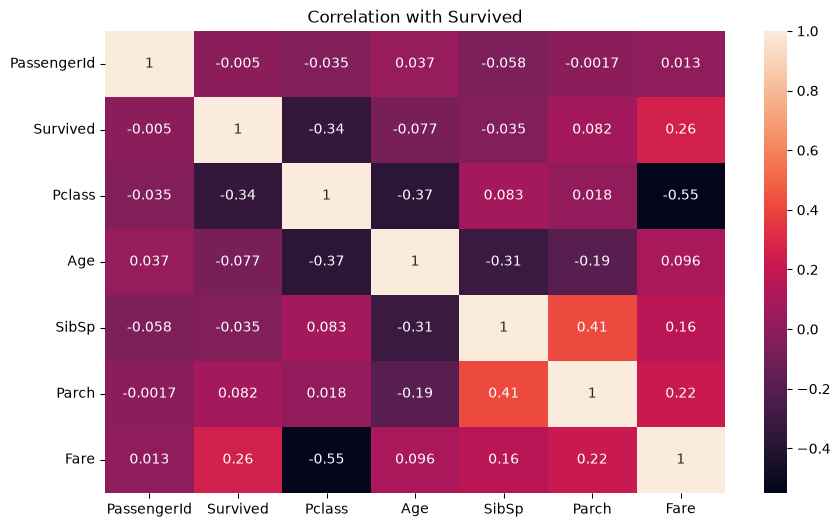

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot = True)
plt.title("Correlation with Survived")
plt.show()

## 5. Data Cleaning

### 5.1 Embarked (2 missing)

In [18]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

### 5.2 Cabin (77% missing)

In [19]:
df['CabinKnown'] = df['Cabin'].notna().astype(int)

### 5.3 Title from Name

In [20]:
# Extract the title (Mr, Mrs, Miss ...) from the name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [21]:
# Group rare titles together
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Countess', 'Lady', 'Sir', 'Don', 'Jonkheer', 'Dona'], 'Rare')

In [22]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

### 5.4 Age (20% missing)

In [23]:
# Fill Age with the median of each Title and Pclass group
df['Age'] = df['Age'].fillna(df.groupby(['Title', 'Pclass'])['Age'].transform('median'))

In [24]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
CabinKnown       0
Title            0
dtype: int64

### 5.5 Outliers

In [25]:
cols = ['Fare', 'Age', 'SibSp', 'Parch']

# IQR method
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(col, '->', n, 'outliers')

Fare -> 116 outliers
Age -> 22 outliers
SibSp -> 46 outliers
Parch -> 213 outliers


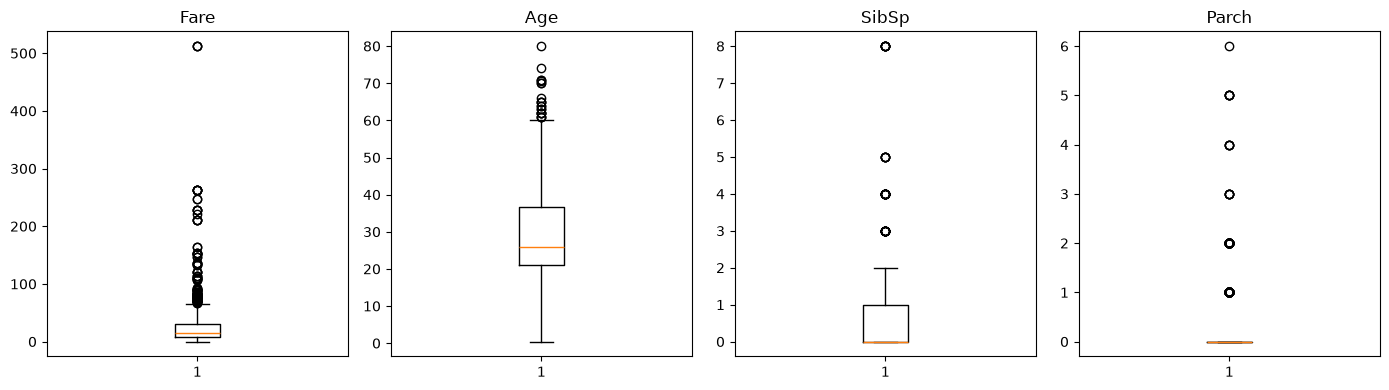

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, cols):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 5.6 Outliers Decision
Outliers are **kept**: they are real passengers (e.g. very high 1st-class fares), and dropping them did not improve the models.

## 6. Feature Engineering

### 6.1 Family Size

In [27]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['FamilyCat'] = pd.cut(df['FamilySize'], bins=[0, 1, 4, 20], labels=['Alone', 'Small', 'Large']).astype(str)

### 6.2 Fare per Person

In [28]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

### 6.3 Ticket Count

In [29]:
df['TicketCount'] = df.groupby('Ticket')['Ticket'].transform('count')

### 6.4 Sex & Pclass Interaction

In [30]:
df['Sex_Pclass'] = df['Sex'] + '_' + df['Pclass'].astype(str)

## 7. Encoding

In [31]:
df['Pclass_cat'] = df['Pclass'].astype(str)

cat_cols = ['Sex', 'Embarked', 'Title', 'FamilyCat', 'Pclass_cat', 'Sex_Pclass']
num_cols = ['Age', 'FarePerPerson', 'CabinKnown', 'TicketCount']

x = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=True, dtype=int)
y = df['Survived']

print('Shape:', x.shape)
x.head()

Shape: (891, 20)


,Age,FarePerPerson,CabinKnown,TicketCount,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilyCat_Large,FamilyCat_Small,Pclass_cat_2,Pclass_cat_3,Sex_Pclass_female_2,Sex_Pclass_female_3,Sex_Pclass_male_1,Sex_Pclass_male_2,Sex_Pclass_male_3
0,22.0,3.62500,0,1,1,0,1,0,1,0,0,0,1,0,1,0,0,0,0,1
1,38.0,35.64165,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
2,26.0,7.92500,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0
3,35.0,26.55000,1,2,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0
4,35.0,8.05000,0,1,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1


## 8. Train / Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [33]:
x_train.shape

(712, 20)

In [34]:
x_test.shape

(179, 20)

## 9. Feature Scaling

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 10. Model Training

In [ ]:
models = {
    # We can use list of different models below:
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SGDClassifier': SGDClassifier(loss='log_loss'),
}

default_acc = {}
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    default_acc[name] = accuracy_score(y_test, model.predict(x_test_scaled))
    print(name, '->', round(default_acc[name], 4))

Logistic Regression -> 0.8212


## 13. Final Evaluation

In [40]:
best_name = max(default_acc, key=default_acc.get)
best_model = models[best_name]

y_pred = best_model.predict(x_test_scaled)

print('Best model :', best_name)
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

Best model : Logistic Regression
              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       105
    Survived       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

